In [1]:
import tonic
import snntorch as snn
import torch.nn as nn
import torch

import numpy as np
import pandas as pd
import random

c:\Users\Veronika\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

SEED=100
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
  torch.cuda.manual_seed_all(SEED)

In [3]:
print(torch.cuda.is_available())

True


In [4]:
dataset = tonic.datasets.NCALTECH101(save_to= './dataset')

3989376000it [05:56, 11189946.66it/s]                                


Extracting ./dataset\NCALTECH101\N-Caltech101-archive.zip to ./dataset\NCALTECH101


In [5]:
events, target = dataset[0]
print(events.shape)
print(target)

(97785,)
BACKGROUND_Google


In [6]:
print(dataset.__dict__.keys())

dict_keys(['location_on_system', 'transform', 'target_transform', 'transforms', 'data', 'targets', 'folder_name'])


In [7]:
classes = sorted(set(dataset.targets))
class_to_idx = {cls: i for i, cls in enumerate(classes)}
dataset.targets = [class_to_idx[target] for target in dataset.targets]

In [8]:
events, target = dataset[5000]
print(events.shape)
print(target)

(230188,)
40


In [9]:
from torch.utils.data import WeightedRandomSampler, random_split

In [10]:
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train, val, test = random_split(dataset, [train_size, val_size, test_size])

In [11]:
train.__dict__.keys()

dict_keys(['dataset', 'indices'])

In [12]:
targets_counts = pd.Series(dataset.targets)

In [13]:
train_target_counts = targets_counts.iloc[train.indices].value_counts()
print(train_target_counts.sum())
print(train_target_counts.head(5).sum())

6967
2192


In [14]:
percentages = train_target_counts * 100 / sum(train_target_counts)
weights = 100 / np.sqrt(percentages)
weights = list(weights)

In [90]:
sampler = WeightedRandomSampler(
    weights = weights,
    num_samples = 6967
)

In [89]:
batch_size = 64

In [91]:
from tonic import DiskCachedDataset, MemoryCachedDataset
from torch.utils.data import DataLoader
    


train_transform = tonic.transforms.Compose([
        tonic.transforms.Downsample(spatial_factor=0.5), 
        tonic.transforms.RandomCrop(sensor_size=(120, 90), target_size=(80, 80)),
        tonic.transforms.RandomFlipLR(sensor_size=(80, 80), p=0.5),
        tonic.transforms.ToFrame(sensor_size=(80, 80, 2), n_time_bins=30) 
    ])


val_transform = tonic.transforms.Compose([
        tonic.transforms.Downsample(spatial_factor=0.5), 
        tonic.transforms.CenterCrop(sensor_size=(120, 90), size=(80, 80)),
        tonic.transforms.ToFrame(sensor_size=(80, 80, 2), n_time_bins=30) 
    ])

cached_train = MemoryCachedDataset(train, transform=train_transform)
cached_val = MemoryCachedDataset(val, transform=val_transform)
cached_test = MemoryCachedDataset(test, transform=val_transform)

train_loader = DataLoader(cached_train, batch_size = batch_size, sampler=sampler, 
                            collate_fn = tonic.collation.PadTensors(batch_first=False), 
                           num_workers=0, pin_memory=True)
            
val_loader = DataLoader(cached_val, batch_size = batch_size, 
                            collate_fn = tonic.collation.PadTensors(batch_first=False), 
                            num_workers=0, pin_memory=True)
    
test_loader = DataLoader(cached_test, batch_size = batch_size,
                            collate_fn = tonic.collation.PadTensors(batch_first=False), 
                            num_workers=0, pin_memory=True)
    

In [43]:
train_size, val_size, test_size

(6967, 870, 872)

In [44]:
len(train_loader) * batch_size, len(val_loader) * batch_size, len(test_loader) * batch_size

(6976, 896, 896)

In [45]:
events, target = cached_train[2000]
print(events.shape)
print(target)

(30, 2, 80, 80)
60


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..17.0].


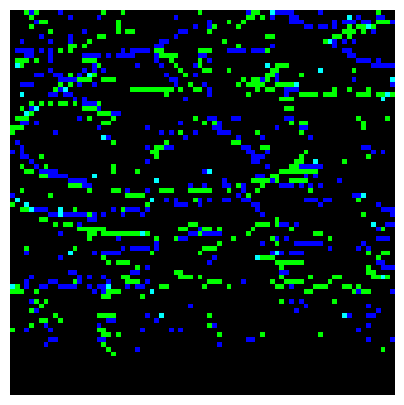

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..17.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..17.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..8.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..13.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..13.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..18.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..15.0].
Clipping input data to the valid range for imshow with RGB data ([0..1

In [46]:
from IPython.display import HTML
animation = tonic.utils.plot_animation(events)
HTML(animation.to_jshtml())

In [93]:
from snntorch import _layers 

In [ ]:
class ConvNet(nn.Module):
  def __init__(self, in_ch, out_ch, beta, threshold, population):
    super().__init__()

    self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size = 3, padding = "same")
    self.mp1 = nn.MaxPool2d(2)
    self.bn_conv1 = _layers.BatchNormTT2d(out_ch, time_steps=30)
    self.lif1 = snn.Leaky(beta=beta, threshold=threshold)#, learn_beta=True, learn_threshold=True)

    self.conv2 = nn.Conv2d(out_ch, out_ch * 2, kernel_size = 3, padding = "same")
    self.mp2 = nn.MaxPool2d(4)
    self.bn_conv2 = _layers.BatchNormTT2d(out_ch * 2, time_steps=30)
    self.lif2 = snn.Leaky(beta=beta, threshold=threshold)#, learn_beta=True, learn_threshold=True)

    #self.conv3 = nn.Conv2d(out_ch * 2, out_ch * 4, kernel_size = 3, padding = "same")
    #self.mp3 = nn.MaxPool2d(2)
    #self.bn_conv3 = _layers.BatchNormTT2d(out_ch * 4, time_steps=30)
    #self.lif3 = snn.Leaky(beta=beta, threshold=threshold)#, learn_beta=True, learn_threshold=True)

    #self.fc1 = nn.Linear(out_ch * 2 * 10 * 10, 512)
    #self.bn_fc1 = snn.BatchNormTT1d(512, time_steps=30)
    #self.lif4 = snn.Leaky(beta=beta, threshold=threshold)#, learn_beta=True, learn_threshold=True)
    #self.dropout = nn.Dropout(p=0.5)

    self.fc2 = nn.Linear(out_ch * 2 * 10 * 10, 101 * population)
    self.lif5 = snn.Leaky(beta=beta, threshold=threshold)#, learn_beta=True, learn_threshold=True)

  def forward(self, x):

    mem1 = self.lif1.init_leaky()
    mem2 = self.lif2.init_leaky()
    #mem3 = self.lif3.init_leaky()
    #mem4 = self.lif4.init_leaky()
    mem5 = self.lif5.init_leaky()

    spk5_rec = []

    for step in range(x.shape[0]):

      cur1 = self.conv1(x[step])
      mp1 = self.mp1(cur1)
      bn1 = self.bn_conv1[step](mp1)
      spk1, mem1 = self.lif1(bn1, mem1)

      cur2 = self.conv2(spk1)
      mp2 = self.mp2(cur2)
      bn2 = self.bn_conv2[step](mp2)
      spk2, mem2 = self.lif2(bn2, mem2)

      #cur3 = self.conv3(spk2)
      #mp3 = self.mp3(cur3)
      #bn3 = self.bn_conv3[step](mp3)
      #spk3, mem3 = self.lif3(bn3, mem3)

      #cur4 = self.fc1(spk3.flatten(1))
      #bn4 = self.bn_fc1[step](cur4)
      #spk4, mem4 = self.lif4(bn4, mem4)
      #drop_spk4 = self.dropout(spk4)

      cur5 = self.fc2(spk2.flatten(1))
      spk5, mem5 = self.lif5(cur5, mem5)

      spk5_rec.append(spk5)

    return torch.stack(spk5_rec, dim = 0), None

In [22]:
convnet = ConvNet(2, 4, beta = 0.9, threshold = 1.0, population = 10).to(device)

In [48]:
from snntorch import functional as SF
import optuna
import joblib

In [119]:
def measure_accuracy(model, dataloader):
  with torch.no_grad():
    model.eval()
    length = 0
    accuracy_rates = 0

    for step, (events, targets) in enumerate(dataloader):
        if step >= 5: 
            break

        events = events.to(device, dtype = torch.float, non_blocking=True)
        targets = targets.to(device, non_blocking=True).long()

        spk_rec, _ = model(events)
        print(f"Liczba impulsów: {spk_rec.sum().item()}")

        print('Obliczenie accuracy')
        accuracy_rates += SF.accuracy_rate(spk_rec, targets, population_code=True, num_classes= 101)
        length += 1

        del spk_rec, events, targets
      
    accuracy = (accuracy_rates * 100 / length) 
    print(f'Accuracy obliczone: {accuracy}%')

    return accuracy

In [ ]:
import gc

In [124]:
def objective(trial):

    lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    beta = trial.suggest_float('beta', 0.70, 0.95)
    threshold = trial.suggest_float('threshold', 0.5, 2, log=True)
    population = trial.suggest_int('population', 5, 15)

    model = ConvNet(in_ch=2, out_ch=4, beta=beta, threshold = threshold, population=population).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.999))
    loss = SF.ce_count_loss(population_code=True, num_classes=101)

    epochs_per_trial = 3

    for epoch in range(epochs_per_trial):
        model.train()
        for step, (events, targets) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}")):
            if step >= 5:
                break

            events = events.to(device, dtype = torch.float, non_blocking=True)
            targets = targets.to(device, non_blocking=True).long()

            optimizer.zero_grad(set_to_none=True)
            spk_rec, _ = model(events)
            
            total_spikes = spk_rec.sum().item()
            print(f"Liczba impulsów: {spk_rec.sum().item()}")

            if step >= 3:
                if total_spikes == 0.0:
                    del spk_rec, events, targets, model, optimizer
                    gc.collect()
                    torch.cuda.empty_cache()
                    raise optuna.exceptions.TrialPruned()

            firing_rates = torch.mean(spk_rec, dim=0)
            l2_penalty = torch.mean(firing_rates ** 2)
            
            loss_val = loss(spk_rec, targets) + 0.01 * l2_penalty
            loss_val.backward()
            optimizer.step()

            del loss_val, spk_rec, events, targets


        print(f'Walidacja')
        val_acc = measure_accuracy(model, val_loader)
        trial.report(val_acc, step=epoch)

        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
    
    print('Czyszczenie pamięci')
    del model, optimizer
    
    gc.collect()
    torch.cuda.empty_cache()

    return val_acc

In [102]:
optimizer = torch.optim.Adam(convnet.parameters(), lr=1e-3, betas=(0.9, 0.999))
criterion = SF.ce_count_loss(population_code=True, num_classes=101)

In [53]:
import torch.profiler as profiler
def train_step(model, dataloader, optimizer, criterion, prof):
    model.train()

    if prof is not None:
        prof.step()

    for i, (inputs, labels) in enumerate(dataloader):
        optimizer.zero_grad()
        inputs = inputs.to(device, dtype = torch.float, non_blocking=True)
        labels = labels.to(device, non_blocking=True).long()
        outputs, _ = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        if prof is not None:
            prof.step()
        if i >= 5:
            break

with profiler.profile(
    activities=[profiler.ProfilerActivity.CPU, 
    profiler.ProfilerActivity.CUDA],
    on_trace_ready=profiler.tensorboard_trace_handler("./log"),
    profile_memory=True,      
    with_stack=True 
) as prof:
    train_step(convnet, train_loader, optimizer, criterion, prof)

print(prof.key_averages().table(sort_by="cuda_time_total"))

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                            aten::empty         0.28%      13.382ms         0.28%      13.382ms       2.513us     281.40 MB     281.40 MB       4.38 GB       4.38 GB          5325  
                                          aten::random_         0.00%      14.200us         0.00%      14.200us      14.200us           0 B           0 B           0 B           0 B             1  
         

In [29]:
from tqdm import tqdm

In [ ]:
n_trials = 10

sampler = optuna.samplers.TPESampler()
pruner = optuna.pruners.SuccessiveHalvingPruner(min_resource=1, reduction_factor=4)
study = optuna.create_study(study_name="optuna_2", sampler=sampler, direction='maximize', pruner=pruner, 
                            storage="sqlite:///optuna_snn_2.db", load_if_exists=True)

In [71]:
best_params = study.best_params
best_params

{'lr': 0.00029994503558559066,
 'beta': 0.8425642603997404,
 'threshold': 0.5574586164295475,
 'population': 7}

In [129]:
params = study.best_params

In [130]:
study.best_trial.value

20.3125

In [144]:
model = ConvNet(in_ch=2, out_ch=4, beta = params['beta'], 
                threshold=params['threshold'], population=params['population']).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr= params['lr'], betas=(0.9, 0.999))
loss = SF.ce_count_loss(population_code=True, num_classes=101)

num_epochs = 30
loss_hist = []
acc_hist = []
counter = 0
best_accuracy = None

for epoch in range(num_epochs):
    model.train()
    epoch_train_loss = 0

    for events, targets in iter(tqdm(train_loader, desc=f"Epoch {epoch+1}")):
        events = events.to(device, dtype = torch.float, non_blocking=True)
        targets = targets.to(device, non_blocking=True).long()

        optimizer.zero_grad(set_to_none=True)
        spk_rec, _ = model(events)        
        loss_val = loss(spk_rec, targets)

        firing_rates = torch.mean(spk_rec, dim=0)
        l2_penalty = torch.mean(firing_rates ** 2)
                    
        loss_val = loss(spk_rec, targets) + 0.01 * l2_penalty
        
        loss_val.backward()
        optimizer.step()

        epoch_train_loss += loss_val.item()

    train_loss = epoch_train_loss / len(train_loader)
    loss_hist.append(train_loss)

    model.eval()
    accuracy_rates = 0

    with torch.no_grad():
        for events, targets in iter(val_loader):
            events = events.to(device, dtype = torch.float, non_blocking=True)
            targets = targets.to(device, non_blocking=True).long()
        
            spk_rec, _ = model(events)
            accuracy_rates += SF.accuracy_rate(spk_rec, targets, population_code=True, num_classes= 101)
                         
    accuracy = (accuracy_rates * 100 / len(val_loader))
    acc_hist.append(accuracy)


    print(f"Epoch {epoch+1}/{num_epochs} \t Train Loss: {train_loss:.4f} \t Val Accuracy: {accuracy:.2f}%")


    if best_accuracy is None or accuracy > best_accuracy:
        best_accuracy = accuracy
        no_improvement_count = 0
    else:
        no_improvement_count += 1

        if no_improvement_count >= 5:
            print(f"Stopping early at epoch{epoch}")
            break

Epoch 1: 100%|██████████| 109/109 [03:44<00:00,  2.06s/it]


Epoch 1/30 	 Train Loss: 16.7381 	 Val Accuracy: 23.46%


Epoch 2: 100%|██████████| 109/109 [04:14<00:00,  2.33s/it]


Epoch 2/30 	 Train Loss: 3.1918 	 Val Accuracy: 22.37%


Epoch 3:   2%|▏         | 2/109 [00:05<04:42,  2.64s/it]


KeyboardInterrupt: 

In [ ]:
#parameters: {'lr': 0.0009404254932702276, 'beta': 0.9075916664807645,
#  'threshold': 0.5831297370849516, 'population': 12}. Best is trial 6 with value: 22.1875

#learn_beta=False, learn_threshold=False

In [125]:
n_trials = 10

sampler = optuna.samplers.TPESampler()
pruner = optuna.pruners.SuccessiveHalvingPruner(min_resource=1, reduction_factor=4)
study = optuna.create_study(study_name="optuna_5", sampler=sampler, direction='maximize', pruner=pruner, 
                            storage="sqlite:///optuna_snn_3.db", load_if_exists=True)

study.optimize(objective, n_trials=n_trials)

df = study.trials_dataframe()

print(f"Best accuracy: {study.best_trial.value:.4f}")
print(f"Best config: {study.best_params}")
joblib.dump(study, 'optuna.pkl')

[I 2026-09-11 23:26:39,880] Using an existing study with `study_name='optuna_5'` instead of creating a new one.
Epoch 1:   0%|          | 0/109 [00:00<?, ?it/s]

Liczba impulsów: 165254.0


Epoch 1:   1%|          | 1/109 [00:02<03:50,  2.13s/it]

Liczba impulsów: 163008.0


Epoch 1:   2%|▏         | 2/109 [00:04<03:41,  2.07s/it]

...

Liczba impulsów: 193934.0


Epoch 2:   5%|▍         | 5/109 [00:10<03:41,  2.13s/it]


Walidacja
Liczba impulsów: 79591.0
Obliczenie accuracy
Liczba impulsów: 78848.0
Obliczenie accuracy


[W 2026-09-11 23:32:37,878] Trial 12 failed with parameters: {'lr': 6.293171218358398e-05, 'beta': 0.9258706211121804, 'threshold': 0.5206321265591524, 'population': 5} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\Veronika\AppData\Local\Programs\Python\Python310\lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\Veronika\AppData\Local\Temp\ipykernel_22400\1411336622.py", line 47, in objective
    val_acc = measure_accuracy(model, val_loader)
  File "C:\Users\Veronika\AppData\Local\Temp\ipykernel_22400\4039386485.py", line 15, in measure_accuracy
    print(f"Liczba impulsów: {spk_rec.sum().item()}")
KeyboardInterrupt
[W 2026-09-11 23:32:37,878] Trial 12 failed with value None.


KeyboardInterrupt: 